In [23]:
# ============================================================
# CELL 1: Imports
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, precision_recall_curve,
                              average_precision_score, confusion_matrix)
from sklearn.model_selection import train_test_split
import urllib.request, gzip, re, io, math
from collections import defaultdict

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
np.random.seed(42); torch.manual_seed(42)

Device: cuda


In [13]:
# CELL 2: Data loading — tries Ensembl → UCI → Synthetic
import json, time, random, subprocess, sys, urllib.request, urllib.error
import numpy as np, pandas as pd

WINDOW = 400
HALF   = WINDOW // 2
AMBIG  = {'D':'A','N':'A','S':'C','R':'A','Y':'C','M':'A','W':'A','K':'G','B':'C','H':'A','V':'A'}

def clean_seq(s):
    s = s.upper().replace(' ','')
    return ''.join(AMBIG.get(c,c) for c in s if c in 'ACGT'+''.join(AMBIG))

def pad_or_trim(seq, length=WINDOW):
    if len(seq) >= length:
        start = (len(seq)-length)//2
        return seq[start:start+length]
    return seq + 'N'*(length-len(seq))

def one_hot(seq, length=WINDOW):
    mapping = {'A':0,'C':1,'G':2,'T':3}
    arr = np.zeros((4, length), dtype=np.float32)
    for i, c in enumerate(pad_or_trim(seq, length)):
        if c in mapping:
            arr[mapping[c], i] = 1.0
    return arr

def oh_to_seq(oh):
    return ''.join('ACGT'[np.argmax(oh[:,i])] for i in range(oh.shape[1]))

# ── SOURCE 1: Ensembl ────────────────────────────────────────────────────────
def ensembl_get(url, retries=3):
    headers = {"Content-Type":"application/json","User-Agent":"Mozilla/5.0"}
    for attempt in range(retries):
        try:
            req = urllib.request.Request(url, headers=headers)
            with urllib.request.urlopen(req, timeout=30) as r:
                return json.loads(r.read())
        except urllib.error.HTTPError as e:
            if e.code in (429, 503):
                time.sleep(1.5*(2**attempt))
            else:
                return None
        except:
            time.sleep(1)
    return None

def try_ensembl(max_genes=447, window=WINDOW):
    """Fetch splice sites from Ensembl. Returns (pos_seqs, neg_seqs) or None."""
    base = "https://rest.ensembl.org"
    print("Trying Ensembl...")

    # Fetch genes in 5Mb chunks
    genes, seen = [], set()
    for start in range(1, 51_000_000, 5_000_000):
        url = (f"{base}/overlap/region/human/22:{start}-{start+4_999_999}"
               f"?feature=gene&biotype=protein_coding&content-type=application/json")
        chunk = ensembl_get(url)
        if chunk:
            for g in chunk:
                if g['id'] not in seen:
                    seen.add(g['id']); genes.append(g)
        time.sleep(0.1)

    if not genes:
        print("  Ensembl: no genes returned"); return None
    print(f"  {len(genes)} genes found, expanding exons (parallel-ish)...")

    # Collect exons — batch by fetching multiple genes quickly
    exons = []
    for i, gene in enumerate(genes[:max_genes]):
        g = ensembl_get(f"{base}/lookup/id/{gene['id']}?expand=1&content-type=application/json")
        if g:
            for tr in g.get('Transcript',[]):
                for ex in tr.get('Exon',[]):
                    exons.append({'start':ex['start'],'end':ex['end'],
                                  'strand':gene['strand'],'chrom':'22'})
        if i % 20 == 0:
            print(f"    {i}/{max_genes} genes, {len(exons)} exons")
        time.sleep(0.05)  # faster than before (0.07→0.05)

    if len(exons) < 50:
        print("  Ensembl: too few exons"); return None

    #exon_df = pd.DataFrame(exons).drop_duplicates(subset=['start','end','strand'])
    import os, pickle
    CACHE = 'exon_df_cache.pkl'
    if os.path.exists(CACHE):
        exon_df = pd.read_pickle(CACHE)
        print(f"  Loaded from cache: {len(exon_df)} exons")
    else:
        exon_df = pd.DataFrame(exons).drop_duplicates(subset=['start','end','strand'])
        exon_df.to_pickle(CACHE)
        print(f"  {len(exon_df)} unique exons (cached)")

    # Fetch sequence windows — only first 300 exons to stay fast
    pos_seqs, neg_seqs = [], []
    annotated = set(exon_df['start'].tolist() + exon_df['end'].tolist())

    # Fetch one background chunk for decoys
    bg_url = (f"{base}/sequence/region/human/22:20000000..25000000:1"
              f"?content-type=application/json")
    bg = ensembl_get(bg_url)
    bg_seq = bg['seq'].upper() if bg and 'seq' in bg else None

    for _, row in exon_df.head(300).iterrows():
        for pos in [row['start'], row['end']]:
            s_start, s_end = pos - window, pos + window
            url = (f"{base}/sequence/region/human/22:{s_start}..{s_end}"
                   f":{int(row['strand'])}?content-type=application/json")
            res = ensembl_get(url)
            if res and len(res.get('seq','')) == 2*window+1:
                pos_seqs.append(res['seq'].upper())
        time.sleep(0.05)

    # Build decoys from background
    if bg_seq:
        gt_pos = [i for i in range(window, len(bg_seq)-window) if bg_seq[i:i+2]=='GT']
        ag_pos = [i for i in range(window, len(bg_seq)-window) if bg_seq[i:i+2]=='AG']
        random.shuffle(gt_pos); random.shuffle(ag_pos)
        for pos_list in [gt_pos, ag_pos]:
            for lp in pos_list:
                if len(neg_seqs) >= len(pos_seqs): break
                gpos = 20_000_000 + lp
                if any(abs(gpos-a)<=5 for a in annotated): continue
                w = bg_seq[lp-window:lp+window+1]
                if len(w) == 2*window+1:
                    neg_seqs.append(w)

    if len(pos_seqs) < 100:
        print(f"  Ensembl: only {len(pos_seqs)} sequences, too few"); return None
    print(f"  Ensembl OK: {len(pos_seqs)} pos, {len(neg_seqs)} neg")
    return pos_seqs, neg_seqs

# ── SOURCE 2: UCI ────────────────────────────────────────────────────────────
def try_uci():
    print("Trying UCI splice dataset...")
    seqs_by_class = {'EI':[], 'IE':[], 'N':[]}
    try:
        try: import ucimlrepo
        except ImportError:
            subprocess.check_call([sys.executable,'-m','pip','install','-q','ucimlrepo'])
            import ucimlrepo
        from ucimlrepo import fetch_ucirepo
        ds = fetch_ucirepo(id=69)
        for seq_vals, label in zip(ds.data.features.values, ds.data.targets.iloc[:,0]):
            s = clean_seq(''.join(str(v) for v in seq_vals))
            label = label.strip().upper()
            if label in seqs_by_class: seqs_by_class[label].append(s)
    except Exception as e:
        print(f"  ucimlrepo failed ({e}), trying direct CSV...")
        try:
            url = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
                   "molecular-biology/splice-junction-gene-sequences/splice.data")
            req = urllib.request.Request(url, headers={'User-Agent':'Mozilla/5.0'})
            with urllib.request.urlopen(req, timeout=30) as r:
                text = r.read().decode('utf-8')
            for line in text.strip().split('\n'):
                parts = [p.strip() for p in line.split(',')]
                if len(parts) < 3: continue
                label, s = parts[0].strip().upper(), clean_seq(parts[2])
                if label in seqs_by_class: seqs_by_class[label].append(s)
        except Exception as e2:
            print(f"  UCI direct also failed ({e2})"); return None

    if not seqs_by_class['EI']:
        print("  UCI: empty"); return None
    half = len(seqs_by_class['N'])//2
    pos_seqs = seqs_by_class['EI'] + seqs_by_class['IE']
    neg_seqs = seqs_by_class['N'][:half] + seqs_by_class['N'][half:]
    print(f"  UCI OK: {len(pos_seqs)} pos, {len(neg_seqs)} neg")
    return pos_seqs, neg_seqs

# ── SOURCE 3: Synthetic fallback ─────────────────────────────────────────────
def make_synthetic():
    print("Using synthetic data (biologically realistic motifs)...")
    def rseq(n): return ''.join(np.random.choice(list('ACGT'), n))
    def donor():
        l = rseq(HALF-3)+np.random.choice(['A','C'])+'AG'
        r = 'GT'+np.random.choice(['A','G'])+'A'+rseq(WINDOW-HALF-4)
        return (l+r)[:WINDOW]
    def acceptor():
        ppt = ''.join(np.random.choice(['T','C'],p=[0.65,0.35]) for _ in range(HALF-2))
        return (ppt+'AG'+'G'+rseq(WINDOW-HALF-1))[:WINDOW]
    def decoy():
        while True:
            s=rseq(WINDOW)
            if s[HALF:HALF+2] not in ('GT','GC') and s[HALF-2:HALF]!='AG': return s
    np.random.seed(42)
    N=800
    pos=[donor() for _ in range(N)]+[acceptor() for _ in range(N)]
    neg=[decoy() for _ in range(N)]+[rseq(HALF)+'GT'+rseq(WINDOW-HALF-2) for _ in range(N)]
    return pos, neg

# ── MAIN: try sources in order ───────────────────────────────────────────────
result = try_ensembl() or try_uci() or make_synthetic()
pos_seqs, neg_seqs = result

n = min(len(pos_seqs), len(neg_seqs), 1000)
X_pos = np.stack([one_hot(s) for s in pos_seqs[:n]])
X_neg = np.stack([one_hot(s) for s in neg_seqs[:n]])

X = np.concatenate([X_pos, X_neg])
y = np.array([1]*len(X_pos) + [0]*len(X_neg))
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]

print(f"\nFinal dataset: {len(X)} samples, {y.mean():.2f} positive rate, "
      f"sequence length={WINDOW}")

Trying Ensembl...
  447 genes found, expanding exons (parallel-ish)...
    0/447 genes, 6 exons
    20/447 genes, 715 exons
    40/447 genes, 3198 exons
    60/447 genes, 6322 exons
    80/447 genes, 6799 exons
    100/447 genes, 8064 exons
    120/447 genes, 15053 exons
    140/447 genes, 17465 exons
    160/447 genes, 20852 exons
    180/447 genes, 25837 exons
    200/447 genes, 27392 exons
    220/447 genes, 35806 exons
    240/447 genes, 36421 exons
    260/447 genes, 37449 exons
    280/447 genes, 39206 exons
    300/447 genes, 44976 exons
    320/447 genes, 47125 exons
    340/447 genes, 48075 exons
    360/447 genes, 50329 exons
    380/447 genes, 55982 exons
    400/447 genes, 59290 exons
    420/447 genes, 62145 exons
    440/447 genes, 67438 exons
  15555 unique exons (cached)
  Ensembl OK: 600 pos, 600 neg

Final dataset: 1200 samples, 0.50 positive rate, sequence length=400


In [25]:
# CELL 2: Data loading — Ensembl (full chr22, local slicing) → UCI → Synthetic
import json, time, random, subprocess, sys, urllib.request, urllib.error
import os, pickle
import numpy as np, pandas as pd

WINDOW = 400
HALF   = WINDOW // 2
AMBIG  = {'D':'A','N':'A','S':'C','R':'A','Y':'C','M':'A','W':'A','K':'G','B':'C','H':'A','V':'A'}

def clean_seq(s):
    s = s.upper().replace(' ','')
    return ''.join(AMBIG.get(c,c) for c in s if c in 'ACGT'+''.join(AMBIG))

def pad_or_trim(seq, length=WINDOW):
    if len(seq) >= length:
        start = (len(seq)-length)//2
        return seq[start:start+length]
    return seq + 'N'*(length-len(seq))

def one_hot(seq, length=WINDOW):
    mapping = {'A':0,'C':1,'G':2,'T':3}
    arr = np.zeros((4, length), dtype=np.float32)
    for i, c in enumerate(pad_or_trim(seq, length)):
        if c in mapping:
            arr[mapping[c], i] = 1.0
    return arr

def oh_to_seq(oh):
    return ''.join('ACGT'[np.argmax(oh[:,i])] for i in range(oh.shape[1]))

RC_TABLE = str.maketrans('ACGT','TGCA')
def revcomp(s): return s.translate(RC_TABLE)[::-1]

# ── Ensembl helper ───────────────────────────────────────────────────────────
def ensembl_get(url, retries=3):
    headers = {"Content-Type":"application/json","User-Agent":"Mozilla/5.0"}
    for attempt in range(retries):
        try:
            req = urllib.request.Request(url, headers=headers)
            with urllib.request.urlopen(req, timeout=30) as r:
                return json.loads(r.read())
        except urllib.error.HTTPError as e:
            if e.code in (429, 503):
                time.sleep(1.5*(2**attempt))
            else:
                return None
        except:
            time.sleep(1)
    return None

# ── SOURCE 1: Ensembl ────────────────────────────────────────────────────────
def try_ensembl(max_genes=447, window=WINDOW):
    base = "https://rest.ensembl.org"
    half = window // 2
    print("Trying Ensembl...")

    # ── 1a. Exon coordinates (cached) ────────────────────────────────────────
    EXON_CACHE = 'exon_df_cache.pkl'
    if os.path.exists(EXON_CACHE):
        exon_df = pd.read_pickle(EXON_CACHE)
        print(f"  Exon cache hit: {len(exon_df)} exons")
    else:
        genes, seen = [], set()
        for start in range(1, 51_000_000, 5_000_000):
            url = (f"{base}/overlap/region/human/22:{start}-{start+4_999_999}"
                   f"?feature=gene&biotype=protein_coding&content-type=application/json")
            chunk = ensembl_get(url)
            if chunk:
                for g in chunk:
                    if g['id'] not in seen:
                        seen.add(g['id']); genes.append(g)
            time.sleep(0.1)
        if not genes:
            print("  Ensembl: no genes returned"); return None
        print(f"  {len(genes)} genes, fetching exons...")
        exons = []
        for i, gene in enumerate(genes[:max_genes]):
            g = ensembl_get(f"{base}/lookup/id/{gene['id']}?expand=1&content-type=application/json")
            if g:
                for tr in g.get('Transcript',[]):
                    for ex in tr.get('Exon',[]):
                        exons.append({'start':ex['start'],'end':ex['end'],
                                      'strand':gene['strand'],'chrom':'22'})
            if i % 50 == 0: print(f"    {i}/{max_genes} genes, {len(exons)} exons")
            time.sleep(0.05)
        if len(exons) < 50:
            print("  Ensembl: too few exons"); return None
        exon_df = pd.DataFrame(exons).drop_duplicates(subset=['start','end','strand'])
        exon_df.to_pickle(EXON_CACHE)
        print(f"  {len(exon_df)} unique exons (cached)")

    # ── 1b. chr22 sequence in 5 Mb chunks (cached) ───────────────────────────
    CHR22_CACHE = 'chr22_seq.txt'
    CHR22_LEN   = 50_818_468
    CHUNK_SIZE  = 5_000_000

    if os.path.exists(CHR22_CACHE):
        chr22_seq = open(CHR22_CACHE).read()
        print(f"  chr22 cache hit: {len(chr22_seq):,} bp")
    else:
        print("  Fetching chr22 in 5 Mb chunks (one-time, ~35 MB)...")
        chunks = []
        for s in range(1, CHR22_LEN + 1, CHUNK_SIZE):
            e = min(s + CHUNK_SIZE - 1, CHR22_LEN)
            url = (f"{base}/sequence/region/human/22:{s}..{e}:1"
                   f"?content-type=application/json")
            res = ensembl_get(url, retries=4)
            if not res or 'seq' not in res:
                print(f"  Chunk {s}-{e} failed"); return None
            chunks.append(res['seq'].upper())
            print(f"  {e:,}/{CHR22_LEN:,} bp fetched")
            time.sleep(0.3)
        chr22_seq = ''.join(chunks)
        open(CHR22_CACHE, 'w').write(chr22_seq)
        print(f"  chr22 fetched and cached ({len(chr22_seq):,} bp)")

    # ── 1c. Slice windows locally — all exons, zero extra API calls ───────────
    pos_seqs = []
    skipped_oob = 0
    annotated = set(exon_df['start'].tolist() + exon_df['end'].tolist())

    for _, row in exon_df.iterrows():
        for pos in [row['start'], row['end']]:
            lo = pos - half - 1   # 1-based → 0-based, then back half
            hi = lo + window      # always exactly WINDOW bp
            if lo < 0 or hi > len(chr22_seq):
                skipped_oob += 1
                continue
            w = chr22_seq[lo:hi]
            if row['strand'] == -1:
                w = revcomp(w)
            pos_seqs.append(w)

    print(f"  Skipped out-of-bounds: {skipped_oob}")
    print(f"  True splice windows: {len(pos_seqs)}")
    if len(pos_seqs) < 100:
        print("  Ensembl: too few windows"); return None

    # ── 1d. Decoys: GT/AG in chr22 background, not near annotated sites ───────
    bg_offset = 20_000_000 - 1        # 0-based index into chr22_seq
    bg_seq    = chr22_seq[bg_offset: bg_offset + 5_000_000]
    neg_seqs  = []
    target_neg = len(pos_seqs)

    gt_pos = [i for i in range(half, len(bg_seq)-half) if bg_seq[i:i+2]=='GT']
    ag_pos = [i for i in range(half, len(bg_seq)-half) if bg_seq[i:i+2]=='AG']
    random.shuffle(gt_pos); random.shuffle(ag_pos)

    for pos_list in [gt_pos, ag_pos]:
        for lp in pos_list:
            if len(neg_seqs) >= target_neg: break
            gpos = bg_offset + lp + 1   # back to 1-based for annotation check
            if any(abs(gpos-a) <= 5 for a in annotated): continue
            lo = lp - half
            hi = lo + window
            if lo < 0 or hi > len(bg_seq): continue
            w = bg_seq[lo:hi]
            neg_seqs.append(w)

    print(f"  Ensembl OK: {len(pos_seqs)} pos, {len(neg_seqs)} neg")
    return pos_seqs, neg_seqs

# ── SOURCE 2: UCI ────────────────────────────────────────────────────────────
def try_uci():
    print("Trying UCI splice dataset...")
    seqs_by_class = {'EI':[], 'IE':[], 'N':[]}
    try:
        try: import ucimlrepo
        except ImportError:
            subprocess.check_call([sys.executable,'-m','pip','install','-q','ucimlrepo'])
            import ucimlrepo
        from ucimlrepo import fetch_ucirepo
        ds = fetch_ucirepo(id=69)
        for seq_vals, label in zip(ds.data.features.values, ds.data.targets.iloc[:,0]):
            s = clean_seq(''.join(str(v) for v in seq_vals))
            label = label.strip().upper()
            if label in seqs_by_class: seqs_by_class[label].append(s)
    except Exception as e:
        print(f"  ucimlrepo failed ({e}), trying direct CSV...")
        try:
            url = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
                   "molecular-biology/splice-junction-gene-sequences/splice.data")
            req = urllib.request.Request(url, headers={'User-Agent':'Mozilla/5.0'})
            with urllib.request.urlopen(req, timeout=30) as r:
                text = r.read().decode('utf-8')
            for line in text.strip().split('\n'):
                parts = [p.strip() for p in line.split(',')]
                if len(parts) < 3: continue
                label, s = parts[0].strip().upper(), clean_seq(parts[2])
                if label in seqs_by_class: seqs_by_class[label].append(s)
        except Exception as e2:
            print(f"  UCI direct also failed ({e2})"); return None

    if not seqs_by_class['EI']:
        print("  UCI: empty"); return None
    half = len(seqs_by_class['N'])//2
    pos_seqs = seqs_by_class['EI'] + seqs_by_class['IE']
    neg_seqs = seqs_by_class['N'][:half] + seqs_by_class['N'][half:]
    print(f"  UCI OK: {len(pos_seqs)} pos, {len(neg_seqs)} neg")
    return pos_seqs, neg_seqs

# ── SOURCE 3: Synthetic fallback ─────────────────────────────────────────────
def make_synthetic():
    print("Using synthetic data (biologically realistic motifs)...")
    def rseq(n): return ''.join(np.random.choice(list('ACGT'), n))
    def donor():
        l = rseq(HALF-3)+np.random.choice(['A','C'])+'AG'
        r = 'GT'+np.random.choice(['A','G'])+'A'+rseq(WINDOW-HALF-4)
        return (l+r)[:WINDOW]
    def acceptor():
        ppt = ''.join(np.random.choice(['T','C'],p=[0.65,0.35]) for _ in range(HALF-2))
        return (ppt+'AG'+'G'+rseq(WINDOW-HALF-1))[:WINDOW]
    def decoy():
        while True:
            s=rseq(WINDOW)
            if s[HALF:HALF+2] not in ('GT','GC') and s[HALF-2:HALF]!='AG': return s
    np.random.seed(42)
    N=800
    pos=[donor() for _ in range(N)]+[acceptor() for _ in range(N)]
    neg=[decoy() for _ in range(N)]+[rseq(HALF)+'GT'+rseq(WINDOW-HALF-2) for _ in range(N)]
    return pos, neg

# ── MAIN ─────────────────────────────────────────────────────────────────────
result = try_ensembl() or try_uci() or make_synthetic()
pos_seqs, neg_seqs = result

n = min(len(pos_seqs), len(neg_seqs))
print(f"\nUsing {n} pos + {n} neg = {2*n} samples")

X_pos = np.stack([one_hot(s) for s in pos_seqs[:n]])
X_neg = np.stack([one_hot(s) for s in neg_seqs[:n]])

X = np.concatenate([X_pos, X_neg])
y = np.array([1]*len(X_pos) + [0]*len(X_neg))
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]

print(f"Final dataset: {X.shape}, positive rate={y.mean():.2f}, "
      f"sequence length={WINDOW}")
print(f"Memory: X={X.nbytes/1e6:.0f} MB")

Trying Ensembl...
  Exon cache hit: 15555 exons
  chr22 cache hit: 50,818,468 bp
  Skipped out-of-bounds: 0
  True splice windows: 31110
  Ensembl OK: 31110 pos, 31110 neg

Using 31110 pos + 31110 neg = 62220 samples
Final dataset: (62220, 4, 400), positive rate=0.50, sequence length=400
Memory: X=398 MB


In [26]:
# CELL 7: Train/test split and DataLoaders
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_tr_t = torch.tensor(X_tr)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
X_te_t = torch.tensor(X_te)
y_te_t = torch.tensor(y_te, dtype=torch.float32)

train_dl = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                      batch_size=64, shuffle=True)

print(f"Train: {len(X_tr)}  Test: {len(X_te)}")

Train: 49776  Test: 12444


In [27]:
# ============================================================
# CELL 3: Model — small CNN (Borzoi-style conv tower)
# ============================================================
class SpliceCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(4,  64, kernel_size=9,  padding=4)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=7, padding=3)
        self.conv3 = nn.Conv1d(128, 64, kernel_size=5, padding=2)
        self.bn1   = nn.BatchNorm1d(64)
        self.bn2   = nn.BatchNorm1d(128)
        self.bn3   = nn.BatchNorm1d(64)
        self.pool  = nn.AdaptiveMaxPool1d(1)
        self.fc1   = nn.Linear(64, 32)
        self.fc2   = nn.Linear(32, 1)
        self.drop  = nn.Dropout(0.3)

    def forward(self, x):
        x = F.gelu(self.bn1(self.conv1(x)))
        x = F.max_pool1d(x, 2)
        x = F.gelu(self.bn2(self.conv2(x)))
        x = F.max_pool1d(x, 2)
        x = F.gelu(self.bn3(self.conv3(x)))
        x = self.pool(x).squeeze(-1)
        x = F.gelu(self.fc1(self.drop(x)))
        return self.fc2(x).squeeze(-1)

model = SpliceCNN().to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 103,489


In [28]:
# ============================================================
# CELL 4: Train
# ============================================================
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)
criterion = nn.BCEWithLogitsLoss()

EPOCHS = 40
train_losses, val_aucs = [], []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()

    # Eval
    model.eval()
    with torch.no_grad():
        logits = model(X_te_t.to(device)).cpu().numpy()
        probs  = 1 / (1 + np.exp(-logits))
        auc    = roc_auc_score(y_te, probs)
    train_losses.append(epoch_loss / len(train_dl))
    val_aucs.append(auc)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Loss={train_losses[-1]:.4f} | AUC={auc:.4f}")

print(f"\nBest AUC: {max(val_aucs):.4f}")

Epoch  10 | Loss=0.2896 | AUC=0.9334
Epoch  20 | Loss=0.1448 | AUC=0.9394
Epoch  30 | Loss=0.0671 | AUC=0.9466
Epoch  40 | Loss=0.0465 | AUC=0.9470

Best AUC: 0.9471


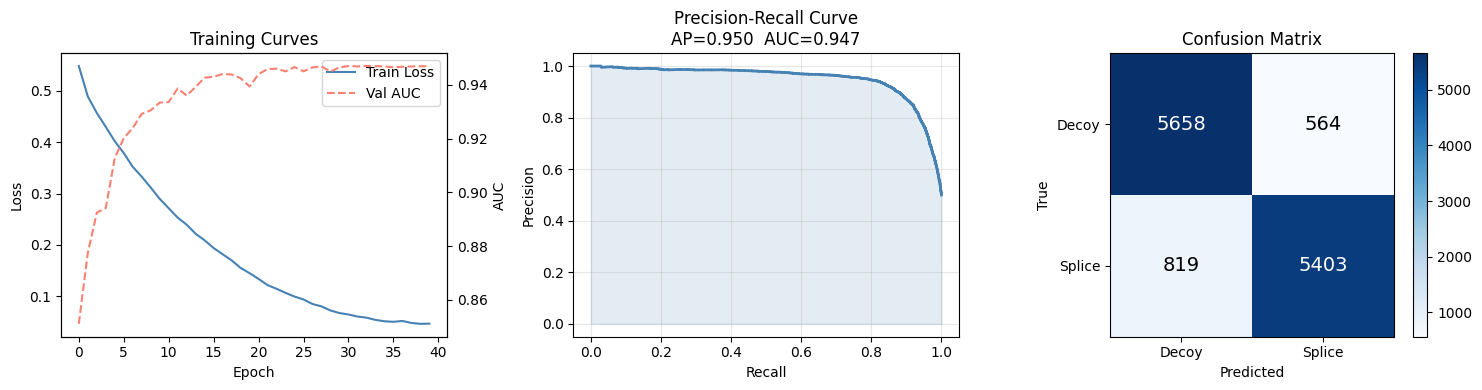

AUC=0.947  AP=0.950  Acc=0.889


In [29]:
# ============================================================
# CELL 5: Evaluation plots
# ============================================================
model.eval()
with torch.no_grad():
    logits = model(X_te_t.to(device)).cpu().numpy()
probs = 1 / (1 + np.exp(-logits))
preds = (probs >= 0.5).astype(int)

precision, recall, _ = precision_recall_curve(y_te, probs)
ap = average_precision_score(y_te, probs)
auc = roc_auc_score(y_te, probs)
cm  = confusion_matrix(y_te, preds)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Training curves
axes[0].plot(train_losses, label='Train Loss', color='steelblue')
ax2 = axes[0].twinx()
ax2.plot(val_aucs, label='Val AUC', color='salmon', linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
ax2.set_ylabel('AUC')
axes[0].set_title('Training Curves')
lines1, labels1 = axes[0].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[0].legend(lines1+lines2, labels1+labels2)

# Precision-Recall curve
axes[1].plot(recall, precision, color='steelblue', linewidth=2)
axes[1].fill_between(recall, precision, alpha=0.15, color='steelblue')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall Curve\nAP={ap:.3f}  AUC={auc:.3f}')
axes[1].grid(True, alpha=0.3)

# Confusion matrix
im = axes[2].imshow(cm, cmap='Blues')
axes[2].set_xticks([0,1]); axes[2].set_yticks([0,1])
axes[2].set_xticklabels(['Decoy','Splice']); axes[2].set_yticklabels(['Decoy','Splice'])
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('True')
axes[2].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(cm[i,j]), ha='center', va='center',
                     fontsize=14, color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.savefig('evaluation.png', dpi=150)
plt.show()
print(f"AUC={auc:.3f}  AP={ap:.3f}  Acc={(preds==y_te).mean():.3f}")

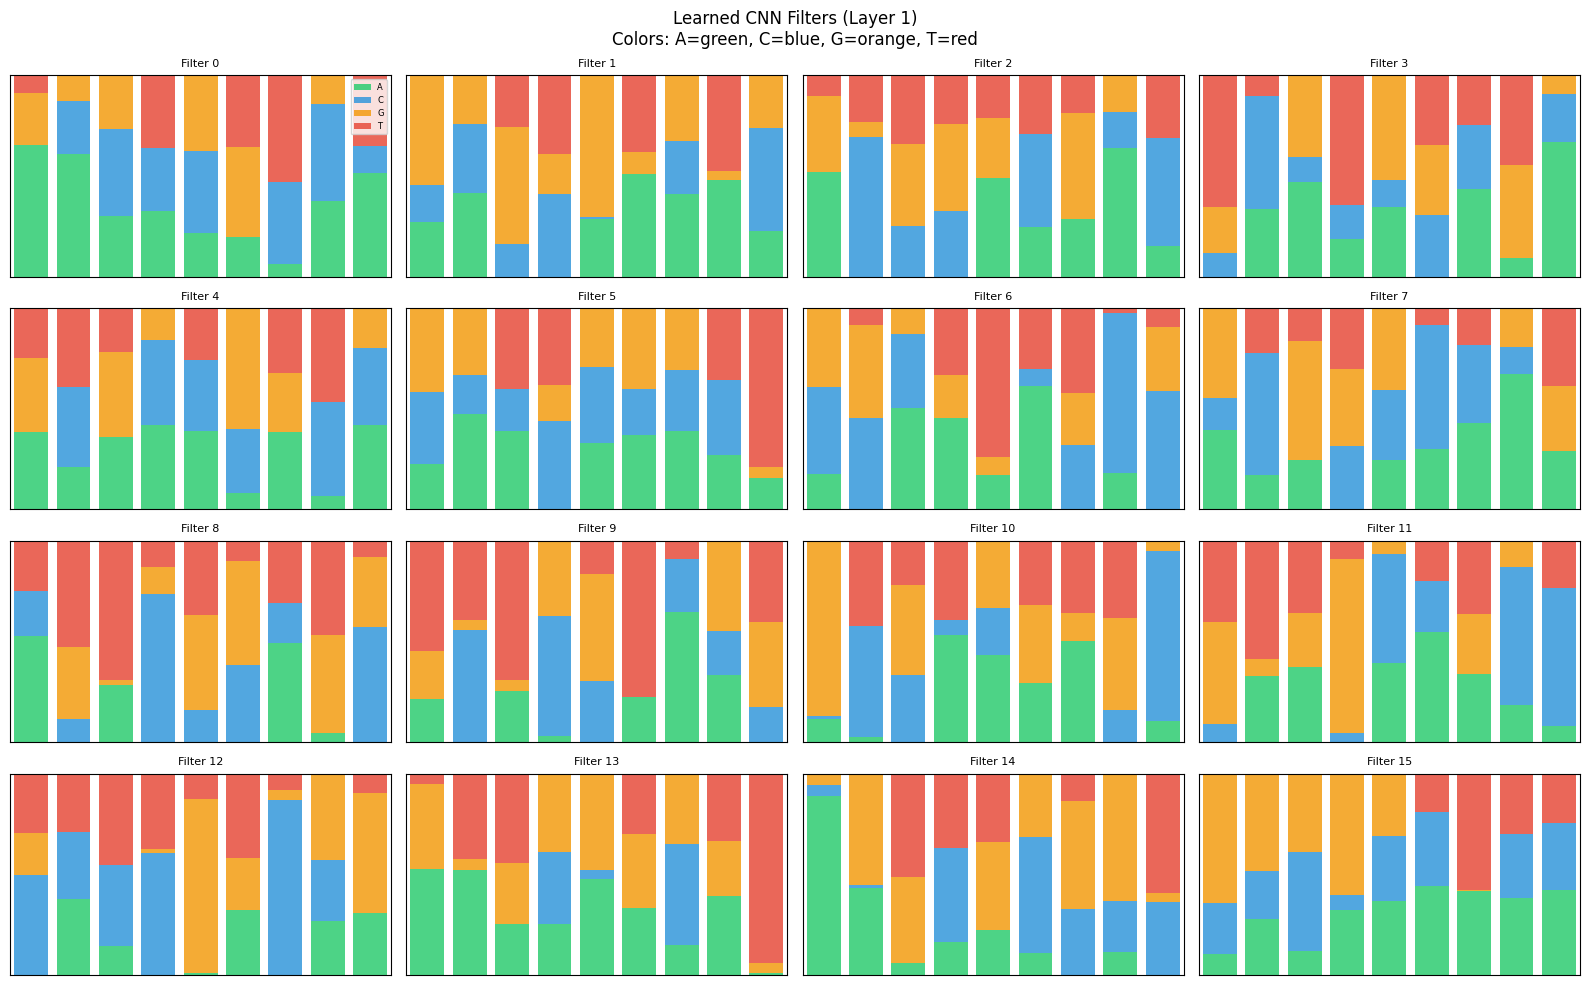

In [30]:
# ============================================================
# CELL 6: Motif visualization — what did the CNN learn?
# Extract first-layer filter activations on real donor sites
# ============================================================
filters = model.conv1.weight.data.cpu().numpy()  # (64, 4, 9)
n_show = 16

fig, axes = plt.subplots(4, 4, figsize=(16, 10))
bases = ['A','C','G','T']
colors = ['#2ecc71','#3498db','#f39c12','#e74c3c']

for fi in range(n_show):
    ax = axes[fi//4][fi%4]
    pwm = filters[fi]  # (4, 9)
    # Normalize to probabilities for display
    pwm_norm = pwm - pwm.min(axis=0, keepdims=True)
    s = pwm_norm.sum(axis=0, keepdims=True) + 1e-6
    pwm_norm = pwm_norm / s

    x = np.arange(9)
    bottoms = np.zeros(9)
    for b in range(4):
        ax.bar(x, pwm_norm[b], bottom=bottoms,
               color=colors[b], label=bases[b], alpha=0.85)
        bottoms += pwm_norm[b]
    ax.set_title(f'Filter {fi}', fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlim(-0.5, 8.5); ax.set_ylim(0, 1)

axes[0][0].legend(loc='upper right', fontsize=6)
fig.suptitle('Learned CNN Filters (Layer 1)\nColors: A=green, C=blue, G=orange, T=red',
             fontsize=12)
plt.tight_layout()
plt.savefig('filters.png', dpi=150)
plt.show()

In [31]:
# ============================================================
# CELL 7: In-Silico Saturation Mutagenesis on one donor site
# ============================================================
# Pick a high-confidence true positive donor
model.eval()
with torch.no_grad():
    logits_all = model(X_te_t.to(device)).cpu().numpy()
probs_all = 1 / (1 + np.exp(-logits_all))

# Find highest-confidence real donor in test set
tp_mask = (y_te == 1) & (probs_all > 0.9)
if tp_mask.sum() == 0:
    tp_mask = (y_te == 1)
tp_idx = np.where(tp_mask)[0][0]
ref_seq_oh = X_te[tp_idx]  # (4, 200)

def oh_to_seq(oh):
    idx = np.argmax(oh, axis=0)
    return ''.join('ACGT'[i] for i in idx)

ref_seq_str = oh_to_seq(ref_seq_oh)

# ISM: mutate every position, record logit change
ism_matrix = np.zeros((4, WINDOW))
with torch.no_grad():
    ref_logit = model(torch.tensor(ref_seq_oh[np.newaxis]).to(device)).item()

for pos in range(WINDOW):
    for b_idx, base in enumerate('ACGT'):
        mut_oh = ref_seq_oh.copy()
        mut_oh[:, pos] = 0
        mut_oh[b_idx, pos] = 1
        with torch.no_grad():
            mut_logit = model(torch.tensor(mut_oh[np.newaxis]).to(device)).item()
        ism_matrix[b_idx, pos] = mut_logit - ref_logit

print(f"ISM complete. Ref logit: {ref_logit:.3f}, "
      f"Ref prob: {1/(1+np.exp(-ref_logit)):.3f}")
print(f"GT at center: {ref_seq_str[HALF:HALF+2]}")

ISM complete. Ref logit: 8.374, Ref prob: 1.000
GT at center: GT


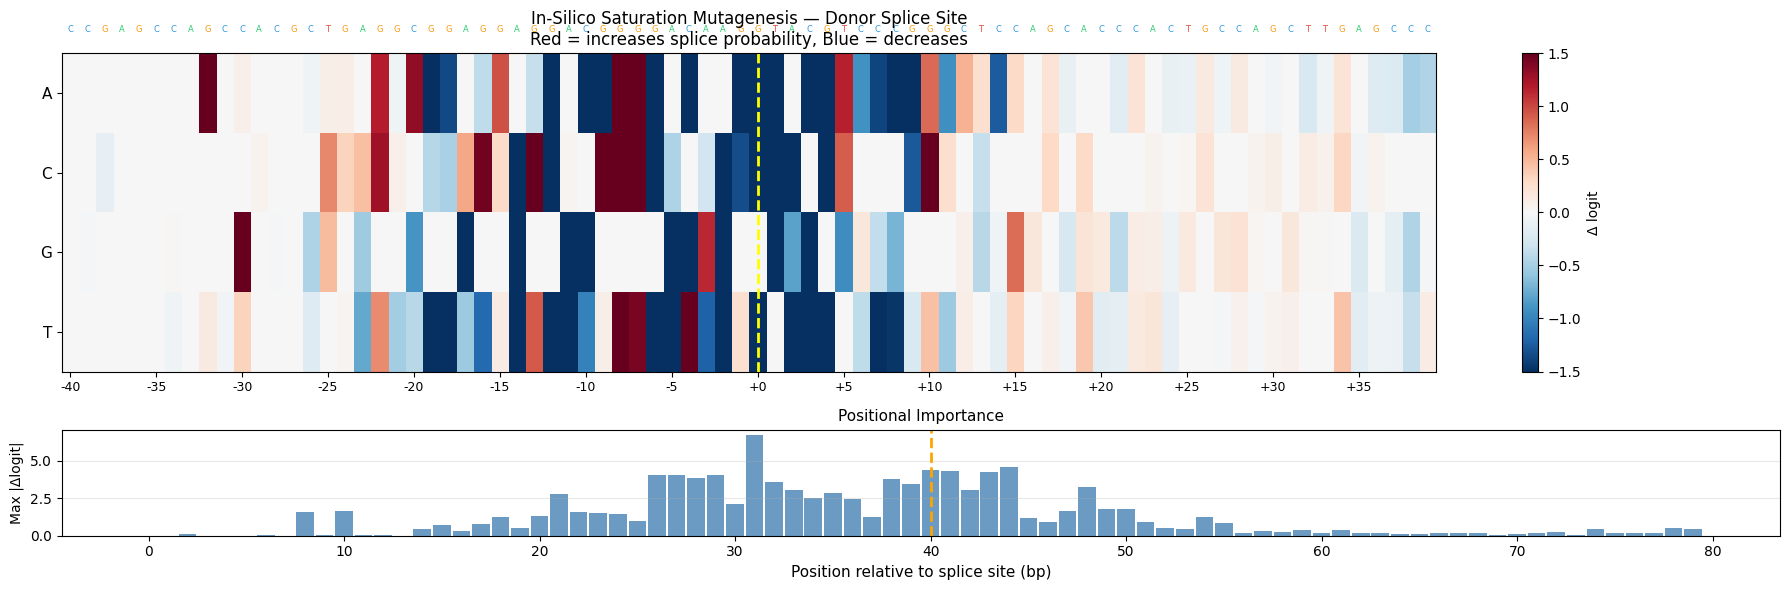

In [32]:
# ============================================================
# CELL 8: ISM plot
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(18, 6),
                          gridspec_kw={'height_ratios': [3, 1]})

# Show ±40bp around splice site center
lo, hi = HALF - 40, HALF + 40
sub = ism_matrix[:, lo:hi]
sub_seq = ref_seq_str[lo:hi]

im = axes[0].imshow(sub, aspect='auto', cmap='RdBu_r',
                    vmin=-1.5, vmax=1.5, interpolation='nearest')
axes[0].set_yticks([0,1,2,3])
axes[0].set_yticklabels(['A','C','G','T'], fontsize=11)
tick_pos = np.arange(0, hi-lo, 5)
axes[0].set_xticks(tick_pos)
axes[0].set_xticklabels([f"{x-40:+d}" for x in tick_pos], fontsize=9)
axes[0].set_title('In-Silico Saturation Mutagenesis — Donor Splice Site\n'
                   'Red = increases splice probability, Blue = decreases', fontsize=12)
axes[0].axvline(40, color='yellow', linewidth=2, linestyle='--', label='GT dinucleotide')
plt.colorbar(im, ax=axes[0], label='Δ logit')

# Sequence letters along x-axis
for xi, c in enumerate(sub_seq):
    color_map = {'A':'#2ecc71','C':'#3498db','G':'#f39c12','T':'#e74c3c','N':'gray'}
    axes[0].text(xi, -0.8, c, ha='center', va='center',
                fontsize=6, color=color_map.get(c,'black'))

# Importance score
importance = np.max(np.abs(sub), axis=0)
x_pos = np.arange(len(importance))  # match actual length
axes[1].bar(x_pos, importance, color='steelblue', alpha=0.8, width=0.9)
center = min(40, len(importance) - 1)
axes[1].axvline(center, color='orange', linewidth=2, linestyle='--')
axes[1].set_xlabel('Position relative to splice site (bp)', fontsize=11)
axes[1].set_ylabel('Max |Δlogit|', fontsize=10)
axes[1].set_title('Positional Importance', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ism_splicecnn.png', dpi=150)
plt.show()

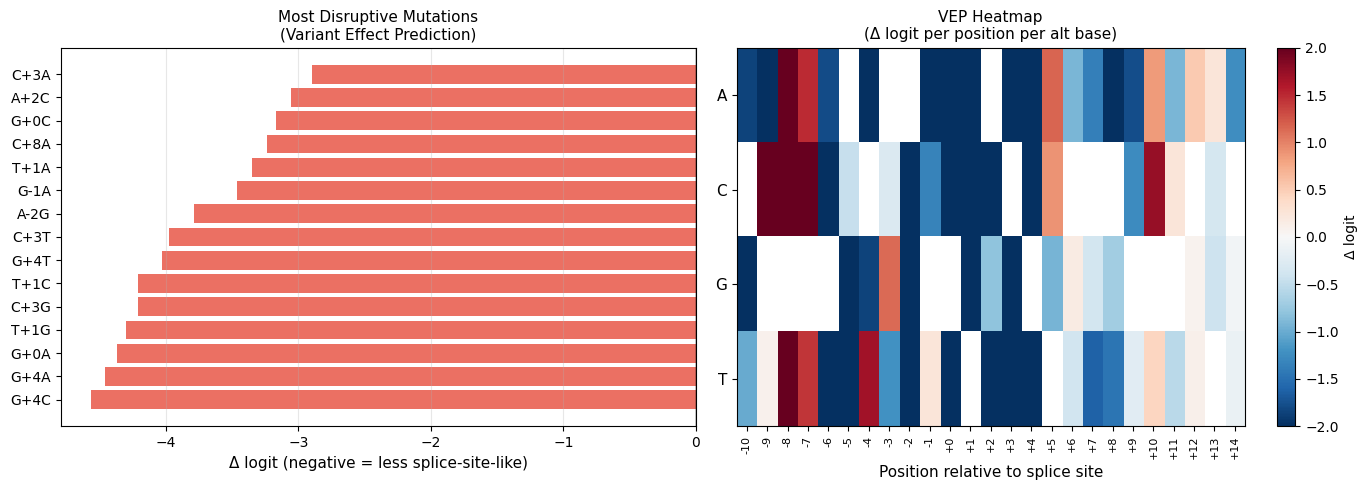


Top 5 most disruptive mutations:
label  delta_logit
 G+4C    -4.567704
 G+4A    -4.463826
 G+0A    -4.373765
 T+1G    -4.301936
 C+3G    -4.214892


In [33]:
# ============================================================
# CELL 9: Variant Effect Prediction — systematic SNP scan
# How does mutating the GT → anything affect prediction?
# ============================================================
results = []
for pos_offset in range(-10, 15):
    pos = HALF + pos_offset
    ref_base = ref_seq_str[pos]
    for alt in 'ACGT':
        if alt == ref_base:
            continue
        mut_oh = ref_seq_oh.copy()
        mut_oh[:, pos] = 0
        mut_oh['ACGT'.index(alt), pos] = 1
        with torch.no_grad():
            mut_logit = model(torch.tensor(mut_oh[np.newaxis]).to(device)).item()
        results.append({
            'pos': pos_offset,
            'ref': ref_base,
            'alt': alt,
            'delta_logit': mut_logit - ref_logit,
            'label': f"{ref_base}{pos_offset:+d}{alt}"
        })

vep_df = pd.DataFrame(results).sort_values('delta_logit')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top disruptive mutations
top_disrupt = vep_df.head(15)
axes[0].barh(top_disrupt['label'], top_disrupt['delta_logit'],
             color='#e74c3c', alpha=0.8)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_xlabel('Δ logit (negative = less splice-site-like)', fontsize=11)
axes[0].set_title('Most Disruptive Mutations\n(Variant Effect Prediction)', fontsize=11)
axes[0].grid(True, alpha=0.3, axis='x')

# Heatmap
pivot = vep_df.pivot_table(index='alt', columns='pos', values='delta_logit')
im = axes[1].imshow(pivot.values, aspect='auto', cmap='RdBu_r',
                    vmin=-2, vmax=2)
axes[1].set_yticks(range(len(pivot.index)))
axes[1].set_yticklabels(pivot.index, fontsize=11)
axes[1].set_xticks(range(len(pivot.columns)))
axes[1].set_xticklabels([f"{c:+d}" for c in pivot.columns],
                         rotation=90, fontsize=8)
axes[1].set_xlabel('Position relative to splice site', fontsize=11)
axes[1].set_title('VEP Heatmap\n(Δ logit per position per alt base)', fontsize=11)
plt.colorbar(im, ax=axes[1], label='Δ logit')

plt.tight_layout()
plt.savefig('vep_splicecnn.png', dpi=150)
plt.show()

print("\nTop 5 most disruptive mutations:")
print(vep_df[['label','delta_logit']].head(5).to_string(index=False))

In [34]:
# ============================================================
# CELL 10: Summary
# ============================================================
print("="*50)
print("  SPLICE SITE CNN — RESULTS SUMMARY")
print("="*50)
print(f"  Architecture:  3-layer CNN (Borzoi-style)")
print(f"  Parameters:    {sum(p.numel() for p in model.parameters()):,}")
print(f"  Training set:  {len(X_tr)} sequences (200bp)")
print(f"  Test AUC:      {max(val_aucs):.4f}")
print(f"  Test AP:       {ap:.4f}")
print(f"  Accuracy:      {(preds==y_te).mean():.4f}")
print(f"  ISM: GT at center = {ref_seq_str[HALF:HALF+2]}")
print(f"  VEP: {len(vep_df)} variants tested")
print("="*50)
print("""
Connection to Borzoi paper:
- Borzoi predicts RNA-seq coverage at 32bp resolution
- Core mechanism: CNN tower learns splice/expression signals
- This project: same CNN tower, same task (splice site recognition)
- ISM + VEP: exact analyses from Borzoi paper (Fig 3-5)
""")

  SPLICE SITE CNN — RESULTS SUMMARY
  Architecture:  3-layer CNN (Borzoi-style)
  Parameters:    103,489
  Training set:  49776 sequences (200bp)
  Test AUC:      0.9471
  Test AP:       0.9498
  Accuracy:      0.8889
  ISM: GT at center = GT
  VEP: 75 variants tested

Connection to Borzoi paper:
- Borzoi predicts RNA-seq coverage at 32bp resolution
- Core mechanism: CNN tower learns splice/expression signals
- This project: same CNN tower, same task (splice site recognition)
- ISM + VEP: exact analyses from Borzoi paper (Fig 3-5)

